# Line Emission Denoising — Conditional DDPM

Per the 2026-06-18 mentor pivot: full-image denoising of line-emission velocity channels (NO
patches), channel-by-channel. This notebook trains the **conditional DDPM only** — the U-Net
baseline (V12, `unet_line_emission_continuum_best.pth`) is already trained; its metrics
(PSNR 32.95dB / SSIM 0.9857 / MSE 0.000681; M0 +69.8%±15.2% / M1 +17.5%±7.8% / M2 +20.1%±14.3%)
are the comparison target below.

**Continuum-subtraction:** each channel has the static continuum removed first — the mean of
the first/last `CONTINUUM_N` line-free channels is subtracted from every channel (dataset +
evaluation), isolating the purely kinematic line emission.

**Dataset:** line-emission FITS cubes, `(201, 600, 600)`, split at the cube level (3 RunID
groups held out for inference only). Channels sampled per cube via the Gaussian sampler
(center 100, ~75% in [50,150]). Each channel downsampled to 256×256, per-channel min-max
normalised to [0,1].

The DDPM predicts the noise added to the clean channel, conditioned on `[dirty, x_t]`,
denoised via **DDIM** (25 steps).

**Kaggle setup:** GPU on, Internet on, `Add Input` → your line-emission Dataset (FITS cubes).
The bootstrap finds it under `/kaggle/input/` and points the split at it. This notebook is
**standalone** — it clones the repo itself (Section 0), so it does not depend on Kaggle's
native GitHub-linked-notebook feature and can be pasted into any blank Kaggle kernel.

**Heads-up:** DDIM sampling a full 201-channel cube is much slower than a U-Net forward pass —
Section 11's 5-cube holdout eval is the slowest cell by far.

## 0. Bootstrap (clone repo for `src/`, locate data)

In [1]:
import os, sys, subprocess, glob

ON_KAGGLE = os.path.exists('/kaggle')
BRANCH = 'midterm-prep'
if ON_KAGGLE:
    REPO='/kaggle/working/EXXA'; PKG=os.path.join(REPO,'DENOISING_DIFFUSION')
    if not os.path.exists(REPO):
        subprocess.run(['git','clone','--branch',BRANCH,'--depth','1','https://github.com/KrishanYadav333/EXXA.git',REPO], check=True)
    else:
        subprocess.run(['git','-C',REPO,'fetch','origin',BRANCH], check=True)
        subprocess.run(['git','-C',REPO,'reset','--hard','origin/'+BRANCH], check=True)
    # pytorch-msssim for the SSIM loss; bettermoments for moment-map evaluation (Sec. 11)
    subprocess.run([sys.executable,'-m','pip','install','-q','--no-deps','pytorch-msssim','bettermoments'], check=True)
    os.chdir(os.path.join(PKG,'notebooks'));  sys.path.insert(0, PKG)
    # find the line-emission data dir under /kaggle/input (contains run_* subfolders)
    # Fail here, loudly, if the dataset is not attached. Returning None instead
    # defers the error to the first os.path.join two cells later, where it reads as
    # "TypeError: expected str ... not NoneType" and says nothing about the cause.
    hits = (glob.glob('/kaggle/input/**/*_dirty.fits', recursive=True)
            or glob.glob('/kaggle/input/**/*dirty*.fits', recursive=True))
    if not hits:
        avail = sorted(glob.glob('/kaggle/input/*'))
        raise FileNotFoundError(
            'No *_dirty.fits found under /kaggle/input.\n'
            'The line-emission Dataset is probably not attached: '
            'Add Input -> Datasets -> your line-emission cubes.\n'
            f'Currently attached: {avail if avail else "(nothing)"}')
    DATA_DIR = os.path.dirname(os.path.dirname(hits[0]))
else:
    if os.path.basename(os.getcwd()) != 'notebooks' and os.path.isdir('notebooks'): os.chdir('notebooks')
    sys.path.insert(0, os.path.abspath('..'))
    DATA_DIR = '../data/Line Emission Data'
print('cwd:', os.getcwd(), '| DATA_DIR:', DATA_DIR)

Cloning into '/kaggle/working/EXXA'...
Updating files: 100% (5217/5217), done.


cwd: /kaggle/working/EXXA/DENOISING_DIFFUSION/notebooks | DATA_DIR: /kaggle/input/datasets/krishanyadav333/line-emission-data/Line Emission Data


## 0b. Pull latest code (re-run anytime — NO kernel restart needed)

After pushing new changes to the `line-emission` branch, re-run this cell to fetch them and
hot-reload the `src/` modules. Then re-run the import cell below. No "Restart & Run All"
required.

In [2]:
# Pull latest from the line-emission branch and hot-reload src/ (no kernel restart).
# Self-contained: works even if the bootstrap cell hasn't run in this kernel.
import os, sys, subprocess

ON_KAGGLE = os.path.exists('/kaggle')
BRANCH = 'midterm-prep'
REPO = '/kaggle/working/EXXA'

if ON_KAGGLE and os.path.exists(REPO):
    subprocess.run(['git', '-C', REPO, 'fetch', 'origin', BRANCH], check=True)
    subprocess.run(['git', '-C', REPO, 'reset', '--hard', 'origin/'+BRANCH], check=True)
    print(subprocess.run(['git', '-C', REPO, 'log', '--oneline', '-1'],
                         capture_output=True, text=True).stdout.strip())
elif ON_KAGGLE:
    print('repo not cloned yet -- run the bootstrap cell (0.) first')

# drop cached project modules so the next `import` picks up the freshly pulled code
for _m in [m for m in list(sys.modules) if m == 'src' or m.startswith('src.')]:
    del sys.modules[_m]
print('src.* cleared from module cache -- now re-run the imports cell below.')

From https://github.com/KrishanYadav333/EXXA
 * branch            midterm-prep -> FETCH_HEAD


HEAD is now at d1f0f66 perf(moments): collapse in strips -- bettermoments needed 13x the cube, not the cubes
d1f0f66 perf(moments): collapse in strips -- bettermoments needed 13x the cube, not the cubes
src.* cleared from module cache -- now re-run the imports cell below.


## 1. Imports, device, config

In [3]:
import time
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

from src.data.cube_split import split_cubes
from src.data.fits_cube_dataset import FITSChannelDataset

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
N_GPU  = torch.cuda.device_count()
SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
print('device:', device, '| GPUs:', N_GPU,
      '->', [torch.cuda.get_device_name(i) for i in range(N_GPU)] if N_GPU else 'cpu')

TARGET_SIZE   = 256     # test 256 first; raise to 300 only if VRAM allows
N_SAMPLES     = 150     # channels per cube (cube has 201; DDPM is data-hungry)

device: cuda | GPUs: 2 -> ['Tesla T4', 'Tesla T4']


## 2. Cube-level split (3 RunID groups held out for inference only)

In [4]:
train_cubes, val_cubes, holdout_cubes = split_cubes(data_dir=DATA_DIR, n_holdout=3,
                                                     val_fraction=0.2, seed=SEED)

CUBE-LEVEL SPLIT (grouped by RunID — no channel-level leakage)
  data_dir          : /kaggle/input/datasets/krishanyadav333/line-emission-data/Line Emission Data
  total cubes       : 14  across 11 distinct RunIDs
  seed=42  n_holdout=3  val_fraction=0.2
----------------------------------------------------------------------
  TRAIN   :  7 cubes | RunIDs ['0006', '0010', '0020', '0022', '0030', '0035']
  VAL     :  2 cubes | RunIDs ['0016', '0036']
  HOLDOUT :  5 cubes | RunIDs ['0002', '0025', '0026']  <-- inference only, NEVER trained/validated
----------------------------------------------------------------------
  HOLDOUT cube folders (reserved for moment-map evaluation):
    - run_0002_00560_rt_00
    - run_0002_00560_rt_01
    - run_0002_00560_rt_04
    - run_0025_01000_rt_04
    - run_0026_00005_rt_04


## 3. Datasets + DataLoaders (full-image 256x256, per-channel norm)

In [5]:
SUBTRACT_CONTINUUM = True     # subtract line-free continuum before training/eval
CONTINUUM_N        = 5        # channels at each end averaged for the continuum estimate
train_ds = FITSChannelDataset(train_cubes, n_samples=N_SAMPLES, target_size=TARGET_SIZE, seed=SEED,
                              subtract_continuum=SUBTRACT_CONTINUUM, continuum_n=CONTINUUM_N)
val_ds   = FITSChannelDataset(val_cubes,   n_samples=N_SAMPLES, target_size=TARGET_SIZE, seed=SEED,
                              subtract_continuum=SUBTRACT_CONTINUUM, continuum_n=CONTINUUM_N)
print('train items:', len(train_ds), '| val items:', len(val_ds))

[FITSChannelDataset] 7 cubes x ~150 channels = 1050 items | target 256x256 | continuum-subtracted (mean of first/last 5 channels)
[FITSChannelDataset] 2 cubes x ~150 channels = 300 items | target 256x256 | continuum-subtracted (mean of first/last 5 channels)
train items: 1050 | val items: 300


## 4. Imports + DDPM-specific config

Reuses `train_ds`/`val_ds`/`train_cubes`/`val_cubes`/`holdout_cubes`/`device`/`SEED`/`TARGET_SIZE`/
`SUBTRACT_CONTINUUM`/`CONTINUUM_N` from Sections 0–3 above — run those cells first.

In [6]:
from src.data.stacked_pair import StackedPairDataset
from src.models.diffusion_unet import default_diffusion_config
from src.training.diffusion import DenoisingDiffusion

EPOCHS_DDPM      = 60
LR_DDPM          = 2e-4   # eps-prediction; higher than the 2e-5 image-gen default (few steps/epoch, ~350 items)
BATCH_SIZE_DDPM  = 8      # 256px DDPM is heavy; probe below shrinks this on OOM (never resolution)
SAMPLING_STEPS   = 25     # DDIM steps for sampling/evaluation
K_AVG            = 4      # posterior-mean: average K reverse draws (PSNR/SSIM want the mean, not one draw)
DENOISE_BS_DDPM  = 8      # channels per sampling batch in section 11 (256px DDIM is memory-heavy)
print('DDPM config: epochs', EPOCHS_DDPM, '| lr', LR_DDPM, '| batch', BATCH_SIZE_DDPM,
      '| DDIM steps', SAMPLING_STEPS, '| K_avg', K_AVG, '| denoise batch', DENOISE_BS_DDPM)

# Cost of section 11 is exactly linear in all three of these:
#   201 channels / DENOISE_BS_DDPM batches  x  SAMPLING_STEPS  x  K_AVG  model calls per cube.
# The smoke test in 10c measures one batch and tells you whether the full run fits.

DDPM config: epochs 60 | lr 0.0002 | batch 8 | DDIM steps 25 | K_avg 4 | denoise batch 8


## 5. Datasets — stack the continuum-subtracted pairs for the DDPM

`train_ds`/`val_ds` (Section 3 above) already yield continuum-subtracted, shared-dirty-scale
`(dirty, clean)` pairs. `StackedPairDataset` just stacks each pair into the `(2,H,W)` tensor the
DDPM trainer expects — no FITS re-read, no re-normalization.

In [7]:
ddpm_train_ds = StackedPairDataset(train_ds)
ddpm_val_ds   = StackedPairDataset(val_ds)
print('DDPM train items:', len(ddpm_train_ds), '| val items:', len(ddpm_val_ds))

def make_ddpm_loaders(bs):
    nw = 4 if ON_KAGGLE else 0
    return (DataLoader(ddpm_train_ds, batch_size=bs, shuffle=True,  num_workers=nw, pin_memory=True),
            DataLoader(ddpm_val_ds,   batch_size=bs, shuffle=False, num_workers=nw, pin_memory=True))
ddpm_train_loader, ddpm_val_loader = make_ddpm_loaders(BATCH_SIZE_DDPM)

DDPM train items: 1050 | val items: 300


## 6. Model — conditional DDPM U-Net at 256px

`default_diffusion_config` targets 64px by default. For 256px, extend `ch_mult` to
`[1,2,2,2,4]` (5 levels: 256->128->64->32->16) so self-attention at 16x16 actually fires — with
the default `[1,2,2,4]` the network only reaches 32x32 and `attn_resolutions=[16]` would never
trigger.

In [8]:
cfg = default_diffusion_config(image_size=TARGET_SIZE)
cfg.model.ch_mult = [1, 2, 2, 2, 4]     # 5 levels -> bottleneck at 16x16 (attn@16 fires)
cfg.model.ema_rate = 0.99      # short run (~few thousand steps): 0.999 lags too far behind
print('config:', 'ch', cfg.model.ch, '| ch_mult', cfg.model.ch_mult,
      '| attn', cfg.model.attn_resolutions, '| T', cfg.diffusion.num_diffusion_timesteps)

CKPT_DDPM = '../results/checkpoints/ddpm_line_emission_continuum_best.pth.tar'
os.makedirs(os.path.dirname(CKPT_DDPM), exist_ok=True)

# quick param count + forward-shape sanity (conditional input = 2 channels [cond, x_t])
_probe = DenoisingDiffusion(config=cfg, device=str(device), lr=LR_DDPM, checkpoint_path=CKPT_DDPM,
                            data_parallel=False)
print('DDPM params:', f'{sum(p.numel() for p in _probe._core.parameters()):,}')
with torch.no_grad():
    _x = torch.randn(2, 2, TARGET_SIZE, TARGET_SIZE, device=device)
    _t = torch.randint(0, cfg.diffusion.num_diffusion_timesteps, (2,), device=device).float()
    _o = _probe._core(_x, _t)
print('forward (2,2,%d,%d) -> %s' % (TARGET_SIZE, TARGET_SIZE, tuple(_o.shape)))
del _probe; torch.cuda.empty_cache()

config: ch 64 | ch_mult [1, 2, 2, 2, 4] | attn [16] | T 1000
DDPM params: 20,682,945
forward (2,2,256,256) -> (2, 1, 256, 256)


## 6b. Restore the trained checkpoint from a previous session

Must run BEFORE section 7. Section 7 decides whether to train by checking whether
`CKPT_DDPM` exists on disk; when this restore sat at 10b instead, a top-to-bottom run
reached section 7 with nothing restored yet, found no checkpoint, and trained 60 epochs
from scratch (~2 h) before 10b later announced the checkpoint it had just made redundant.

Training is ~2 h; the holdout evaluation is a separate ~15-45 min and is what usually runs out
of session. Re-running the whole notebook to redo the evaluation would retrain for two hours
first, which is pure waste.

The checkpoint lives inside `/kaggle/working/EXXA`, wiped by the bootstrap's `git reset --hard`
and not carried between sessions. Section 12 copies it to the top level of `/kaggle/working`,
where it becomes the notebook's **Output**.

**To evaluate without retraining:** `Add Input` -> `Notebook Output` -> the previous version of
this notebook, then run sections 0-6, this cell, and 11. Sections 7-10 (training and its plots)
can be skipped entirely.

In [9]:
import glob, shutil

# pull the checkpoint (and any completed per-cube results) back from a previous session
restored = 0
if ON_KAGGLE:
    # Checkpoints are chosen by LOWEST best_val_loss, not by mtime. Separate sessions
    # produce separate lineages, and the newest is not the best: one restore brought back
    # epoch 54 / best_val 19.6441 while a previous session had reached epoch 44 / 17.7247.
    # Section 11 would then have been evaluated with the worse weights, with nothing in the
    # output to show it -- "best_val went UP across epochs" is the only symptom, and it is
    # easy to read as noise.
    ck_hits = sorted(glob.glob("/kaggle/input/**/ddpm_line_emission_continuum_best.pth.tar",
                               recursive=True))
    if ck_hits and not os.path.exists(CKPT_DDPM):
        scored = []
        for h in ck_hits:
            try:
                _c = torch.load(h, map_location='cpu', weights_only=False)
                scored.append((float(_c.get('best_val_loss', float('inf'))),
                               int(_c.get('epoch', 0)), h))
                del _c
            except Exception as e:
                print('  unreadable checkpoint skipped:', h, '--', e)
        for bv, ep, h in sorted(scored):
            print(f'  candidate: epoch {ep:>3} | best_val {bv:.4f} | {h}')
        if scored:
            bv, ep, h = sorted(scored)[0]
            os.makedirs(os.path.dirname(CKPT_DDPM), exist_ok=True)
            shutil.copy2(h, CKPT_DDPM); restored += 1
            print(f'restored BEST checkpoint (epoch {ep}, best_val {bv:.4f})')

    _csv_dst = '../results/moment_map_holdout_summary_ddpm.csv'
    _csv_hits = sorted(glob.glob("/kaggle/input/**/moment_map_holdout_summary_ddpm.csv",
                                 recursive=True), key=os.path.getmtime)
    if _csv_hits and not os.path.exists(_csv_dst):
        os.makedirs(os.path.dirname(_csv_dst), exist_ok=True)
        shutil.copy2(_csv_hits[-1], _csv_dst); restored += 1
        print('restored', os.path.basename(_csv_dst), 'from', _csv_hits[-1])

if os.path.exists(CKPT_DDPM):
    _ck = torch.load(CKPT_DDPM, map_location='cpu', weights_only=False)
    print(f"\ncheckpoint present: epoch {_ck.get('epoch')} | "
          f"best_val {float(_ck.get('best_val_loss', float('nan'))):.4f}")
    print('-> sections 7-10 (training) can be SKIPPED; run 10c (smoke test) then section 11')
    del _ck
else:
    print('no checkpoint found -- section 7 must run (about 2 h)')

no checkpoint found -- section 7 must run (about 2 h)


## 7. Train — 60 epochs, conditional eps-loss, DDIM eval

`DenoisingDiffusion` auto-wraps in `nn.DataParallel` on multi-GPU (Kaggle T4x2), keeps EMA +
saves the best (lowest val-loss) checkpoint from the unwrapped model. An OOM-safe probe shrinks
the batch (never the resolution) if 256px doesn't fit.

In [10]:
# OOM-safe batch probe (256px fixed; shrink batch only)
def probe_ddpm_batch(bs0):
    bs = bs0
    while bs >= 1:
        try:
            dd = DenoisingDiffusion(config=cfg, device=str(device), lr=LR_DDPM, checkpoint_path=CKPT_DDPM)
            tl, _ = make_ddpm_loaders(bs)
            x, _ = next(iter(tl)); x = x.to(device)
            from src.training.diffusion import data_transform, noise_estimation_loss
            x = data_transform(x)
            e = torch.randn_like(x[:, 1:, :, :])
            t = torch.randint(0, dd.num_timesteps, (x.size(0),), device=device)
            loss = noise_estimation_loss(dd.model, x, t, e, dd.betas)
            loss.backward()
            del dd, loss, x, e; torch.cuda.empty_cache()
            return bs
        except RuntimeError as ex:
            if 'out of memory' not in str(ex).lower(): raise
            torch.cuda.empty_cache(); bs //= 2
            print(f'[OOM] reducing batch -> {bs} (image stays {TARGET_SIZE})')
    raise RuntimeError('does not fit even at batch 1')

BATCH_DDPM_USED = probe_ddpm_batch(BATCH_SIZE_DDPM)
gpu_note = f'DataParallel x{N_GPU} (~{max(1,BATCH_DDPM_USED // max(N_GPU,1))}/GPU)' if N_GPU > 1 else 'single GPU'
print(f'BATCH SIZE USED: {BATCH_DDPM_USED} at {TARGET_SIZE}x{TARGET_SIZE}  [{gpu_note}]')
ddpm_train_loader, ddpm_val_loader = make_ddpm_loaders(BATCH_DDPM_USED)

BATCH SIZE USED: 8 at 256x256  [DataParallel x2 (~4/GPU)]


In [11]:
diffusion = DenoisingDiffusion(config=cfg, device=str(device), lr=LR_DDPM, checkpoint_path=CKPT_DDPM)

# A fresh trainer starts best_val_loss at inf and start_epoch at 0. If this cell runs on a
# session that already has a checkpoint -- which happens on any top-to-bottom "Save & Run
# All" of a resumed session, not just an intentional retrain -- training would silently
# COLD-START: random weights, and the first epoch's real (bad, undertrained) val loss reads
# as an "improvement" over inf, overwriting the good checkpoint with a worse one. This is
# why best_val_loss was rising across sessions (17.72 -> 19.64 -> 21.65) instead of falling.
# Loading first makes this cell resume by construction; skip it via 10b if you don't want
# ANY further training this session.
FORCE_RETRAIN = False   # set True to train EPOCHS_DDPM more epochs on top of a finished run

if os.path.exists(CKPT_DDPM):
    diffusion.load_checkpoint(CKPT_DDPM)

# Loading first is what stops the cold-start that was overwriting good checkpoints with
# worse ones. But resuming unconditionally is its own tax: a top-to-bottom "Save & Run All"
# then trains EPOCHS_DDPM MORE epochs every session -- 2.4 h before section 11, the cell
# actually being waited on, even gets to start. Train only if the checkpoint has not
# already reached the target.
_epochs_done = diffusion.start_epoch
# Train only the REMAINDER, not a whole extra run. This read `else EPOCHS_DDPM`, so a
# checkpoint at epoch 55 against a target of 60 trained 60 more epochs to reach 115 --
# 1.9 h to cover a 5-epoch shortfall, before section 11 could even start.
_todo = EPOCHS_DDPM if FORCE_RETRAIN else max(0, EPOCHS_DDPM - _epochs_done)

if _todo:
    print(f'training {_todo} epochs (checkpoint at epoch {_epochs_done})')
    t0 = time.time()
    history = diffusion.train(ddpm_train_loader, ddpm_val_loader, n_epochs=_todo, log_every=1)
    print(f'\ntrained {_todo} epochs in {time.time()-t0:.0f}s')
    print('best val loss:', round(diffusion.best_val_loss, 4), '-> checkpoint', CKPT_DDPM)
else:
    print(f'checkpoint already at epoch {_epochs_done} >= EPOCHS_DDPM ({EPOCHS_DDPM})'
          ' -- SKIPPING training. Set FORCE_RETRAIN=True to train further.')
    history = {'train_losses': diffusion.train_losses, 'val_losses': diffusion.val_losses,
               'best_val_loss': diffusion.best_val_loss}
    print('best val loss:', round(float(diffusion.best_val_loss), 4))

training 60 epochs (checkpoint at epoch 0)
Conditional DDPM training
  params : 20,682,945
  device : cuda (DataParallel x2), timesteps: 1000
[epoch   1/60] train 11917.1161 | val 731.6422  *best  (105.0s)
[epoch   2/60] train 312.7023 | val 270.2773  *best  (117.1s)
[epoch   3/60] train 184.4129 | val 249.1790  *best  (115.2s)
[epoch   4/60] train 132.4082 | val 106.5849  *best  (114.7s)
[epoch   5/60] train 112.5321 | val 125.8716  (114.4s)
[epoch   6/60] train 102.2804 | val 126.6078  (113.9s)
[epoch   7/60] train 78.6207 | val 63.0811  *best  (114.7s)
[epoch   8/60] train 81.2493 | val 52.1607  *best  (115.0s)
[epoch   9/60] train 61.2767 | val 118.4257  (114.4s)
[epoch  10/60] train 47.1652 | val 60.0282  (114.4s)
[epoch  11/60] train 64.9182 | val 68.5849  (114.4s)
[epoch  12/60] train 39.7323 | val 48.2229  *best  (115.2s)
[epoch  13/60] train 58.8539 | val 110.1918  (114.8s)
[epoch  14/60] train 53.3957 | val 59.1466  (114.7s)
[epoch  15/60] train 43.5115 | val 45.5101  *best  

## 8. Loss curve (DDPM)

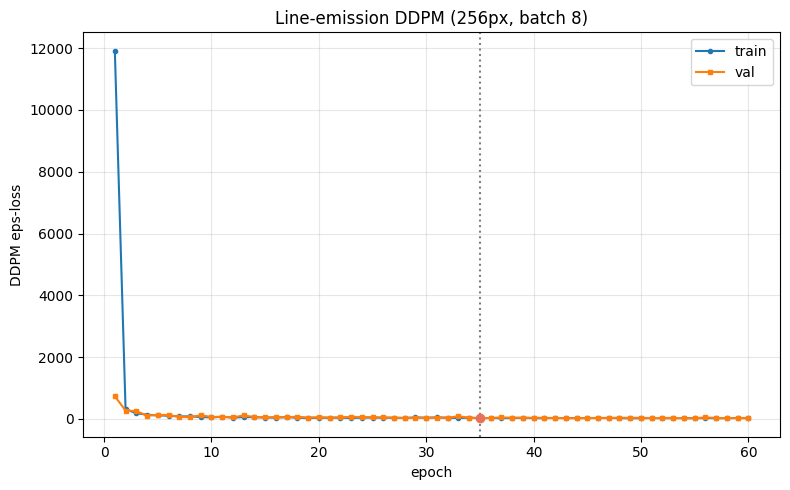

In [12]:
tr_hist = history['train_losses']; va_hist = history['val_losses']
plt.figure(figsize=(8,5))
plt.plot(range(1,len(tr_hist)+1), tr_hist, marker='o', ms=3, label='train')
if va_hist:
    plt.plot(range(1,len(va_hist)+1), va_hist, marker='s', ms=3, label='val')
    be = int(np.argmin(va_hist)) + 1
    plt.axvline(be, color='gray', ls=':'); plt.scatter([be],[min(va_hist)], color='#E8715A', zorder=5)
plt.xlabel('epoch'); plt.ylabel('DDPM eps-loss')
plt.title(f'Line-emission DDPM ({TARGET_SIZE}px, batch {BATCH_DDPM_USED})')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
os.makedirs('../results', exist_ok=True)
plt.savefig('../results/ddpm_line_emission_loss.png', dpi=140); plt.show()

## 9. Validation metrics — PSNR / SSIM / MSE (DDIM-sampled)

`evaluate` DDIM-samples each validation channel from its dirty condition and scores against
clean. Uses EMA weights. Slower than a U-Net forward pass — this is the sampler running per
channel.

In [13]:
val_metrics_ddpm = diffusion.evaluate(ddpm_val_loader, sampling_timesteps=SAMPLING_STEPS, use_ema=True, n_avg=K_AVG)
print('Validation ({} channels):  PSNR {:.4f} dB | SSIM {:.4f} | MSE {:.6f}'.format(
    val_metrics_ddpm['n'], val_metrics_ddpm['psnr'], val_metrics_ddpm['ssim'], val_metrics_ddpm['mse']))

Validation (300 channels):  PSNR 18.2968 dB | SSIM 0.5085 | MSE 0.032940


## 10. Visualize 5 random validation channels — dirty | DDPM denoised | clean

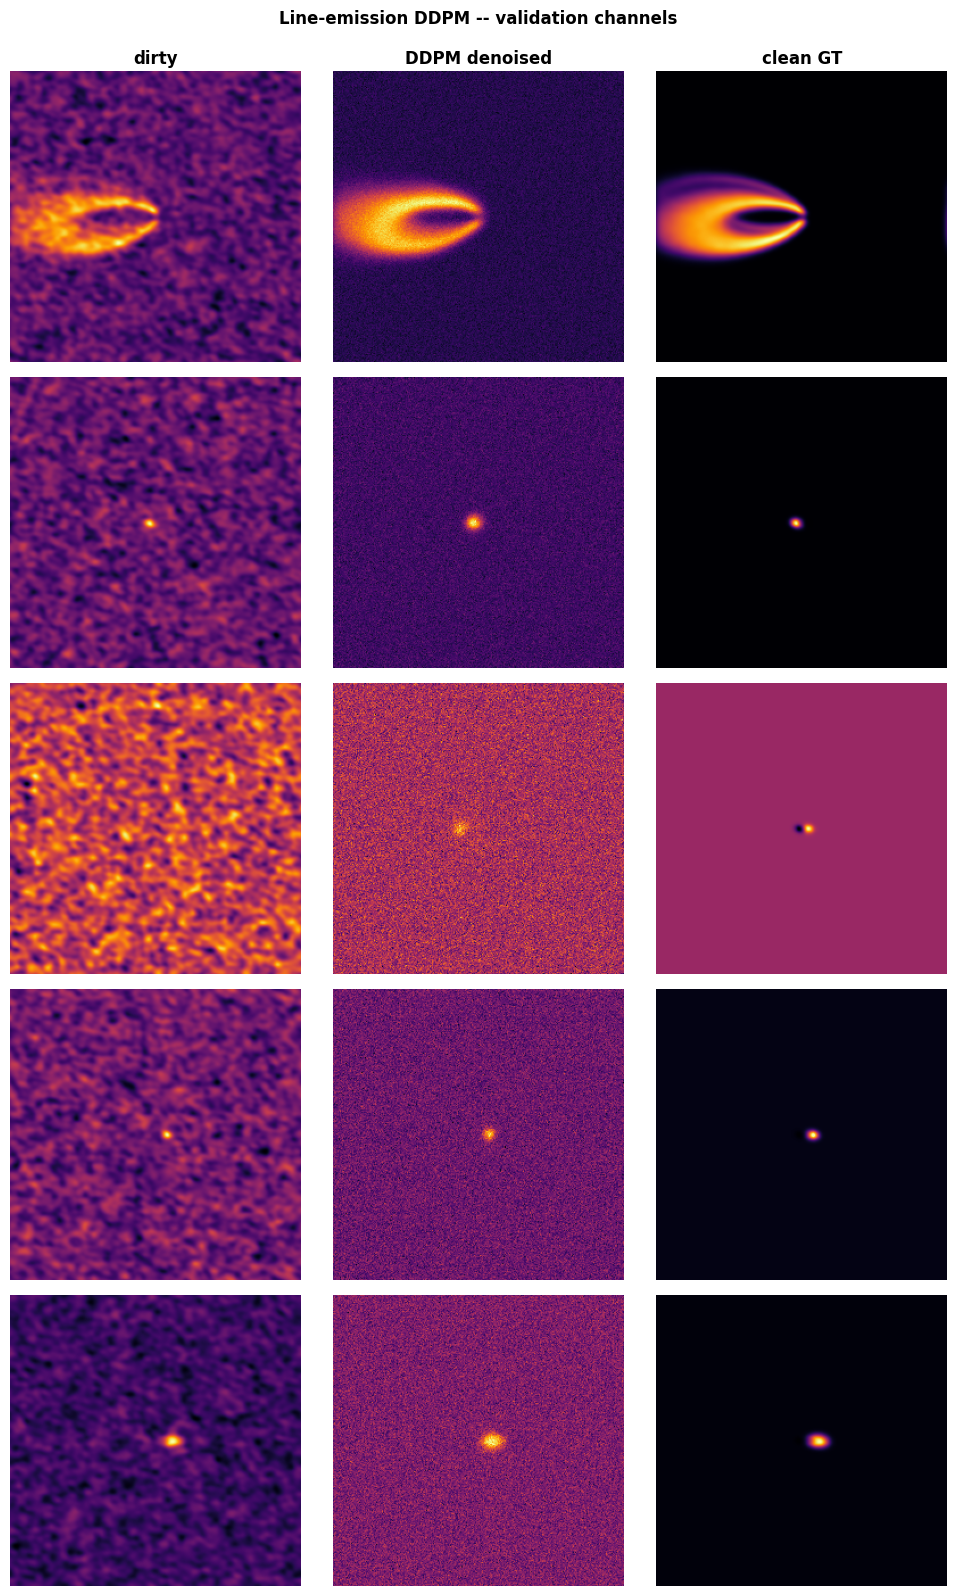

saved -> experiments/line_emission_ddpm_comparison.png


In [14]:
import random
idxs = random.Random(SEED).sample(range(len(val_ds)), 5)
fig, ax = plt.subplots(5, 3, figsize=(10, 16))
cols = ['dirty', 'DDPM denoised', 'clean GT']
for k, t in enumerate(cols): ax[0,k].set_title(t, fontweight='bold')
for r, ix in enumerate(idxs):
    d, c = val_ds[ix]                                     # each (1,H,W), [0,1] shared scale
    pred = diffusion.sample(d[None], sampling_timesteps=SAMPLING_STEPS, use_ema=True, n_avg=K_AVG)[0,0].cpu().numpy()
    ci, ch = val_ds.index[ix]
    for col, im in enumerate([d[0].numpy(), pred, c[0].numpy()]):
        ax[r,col].imshow(np.clip(im,0,1), cmap='inferno'); ax[r,col].axis('off')
    ax[r,0].set_ylabel(f'{val_ds.cube_paths[ci][2]}\nch {ch}', fontsize=8)
fig.suptitle('Line-emission DDPM -- validation channels', fontweight='bold', y=0.995)
plt.tight_layout()
os.makedirs('../experiments', exist_ok=True)
plt.savefig('../experiments/line_emission_ddpm_comparison.png', dpi=140); plt.show()
print('saved -> experiments/line_emission_ddpm_comparison.png')

## 10c. Smoke test — measure DDIM cost before committing to the full run

Section 11 prints nothing until the first batch of `DENOISE_BS_DDPM` channels has run
`SAMPLING_STEPS x K_AVG` = 100 model calls, so **a session that is merely slow is
indistinguishable from one that has hung** — which is how the last two attempts ended with
`denoising run_0002_00560_rt_00 ...` and no further output.

This cell samples one batch, times it, and extrapolates to all 5 held-out cubes. Run it
first; only start section 11 once the projection fits the session budget.


In [15]:
# Smoke test: is section 11 broken, or just slow? Time one batch and extrapolate.
import time

print('device:', device, '| GPUs:', N_GPU)
if torch.cuda.is_available():
    for i in range(N_GPU):
        _free, _tot = torch.cuda.mem_get_info(i)
        print('  GPU{} {}: {:.1f} / {:.1f} GiB free'.format(
            i, torch.cuda.get_device_name(i), _free / 2**30, _tot / 2**30))
else:
    print('  *** NO GPU ***  DDIM sampling on CPU is ~50x slower -- section 11 cannot finish')
    print('  in a Kaggle session. Set Accelerator to GPU T4 x2 and re-run from section 0.')

_smoke = DenoisingDiffusion(config=cfg, device=str(device), lr=LR_DDPM, checkpoint_path=CKPT_DDPM)
_smoke.load_checkpoint(CKPT_DDPM)

_x = torch.rand(DENOISE_BS_DDPM, 1, TARGET_SIZE, TARGET_SIZE)
_smoke.sample(_x[:1], sampling_timesteps=2, use_ema=True, n_avg=1)   # warm up cuDNN autotune
if torch.cuda.is_available():
    torch.cuda.synchronize()

_t = time.time()
_out = _smoke.sample(_x, sampling_timesteps=SAMPLING_STEPS, use_ema=True, n_avg=K_AVG)
if torch.cuda.is_available():
    torch.cuda.synchronize()
_dt = time.time() - _t

# the sampler is exercised on the real batch shape, so these two catch a broken path
# (wrong shape, NaN from the loaded weights) in seconds instead of hours
assert tuple(_out.shape) == (DENOISE_BS_DDPM, 1, TARGET_SIZE, TARGET_SIZE), _out.shape
assert torch.isfinite(_out).all(), 'sampler produced non-finite output -- checkpoint is bad'
print('\nsampler OK: {} -> {}, range [{:.3f}, {:.3f}]'.format(
    tuple(_x.shape), tuple(_out.shape), float(_out.min()), float(_out.max())))

_C = 201                                   # channels per cube
_batches = -(-_C // DENOISE_BS_DDPM)
_per_cube = _dt * _batches / 60.0
_total_h = _per_cube * len(holdout_cubes) / 60.0
print('one batch of {} channels: {:.1f} s  ({} DDIM steps x K_AVG {} = {} model calls)'.format(
    DENOISE_BS_DDPM, _dt, SAMPLING_STEPS, K_AVG, SAMPLING_STEPS * K_AVG))
print('projected: {:.1f} min/cube  ->  {:.1f} h for {} held-out cubes'.format(
    _per_cube, _total_h, len(holdout_cubes)))

BUDGET_H = 6.0    # headroom inside Kaggle's 9 h session limit
if _total_h > BUDGET_H:
    print('\n*** TOO SLOW: {:.1f} h exceeds the {:.0f} h budget ({:.1f}x over).'.format(
        _total_h, BUDGET_H, _total_h / BUDGET_H))
    print('    Section 11 checkpoints per cube, so it CAN be spread over several sessions')
    print('    as-is. To fit one session instead, cut either knob in section 4 (both linear):')
    print('      K_AVG          {} -> 2   halves cost; posterior mean is noisier'.format(K_AVG))
    print('      SAMPLING_STEPS {} -> 15  cuts ~40%; DDIM holds up well down to ~15'.format(
        SAMPLING_STEPS))
    print('    Then re-run this cell to confirm before starting section 11.')
else:
    print('\nOK: {:.1f} h fits the {:.0f} h budget. Run section 11.'.format(_total_h, BUDGET_H))

del _smoke, _x, _out
if torch.cuda.is_available():
    torch.cuda.empty_cache()


device: cuda | GPUs: 2
  GPU0 Tesla T4: 5.2 / 14.6 GiB free
  GPU1 Tesla T4: 5.8 / 14.6 GiB free
=> loaded '../results/checkpoints/ddpm_line_emission_continuum_best.pth.tar' (epoch 35, step 4620)

sampler OK: (8, 1, 256, 256) -> (8, 1, 256, 256), range [0.348, 0.621]
one batch of 8 channels: 28.4 s  (25 DDIM steps x K_AVG 4 = 100 model calls)
projected: 12.3 min/cube  ->  1.0 h for 5 held-out cubes

OK: 1.0 h fits the 6 h budget. Run section 11.


## 11. All-5-Holdout Evaluation (Continuum-Subtracted, DDPM)

Denoising uses DDIM sampling instead of a U-Net forward pass. Directly comparable to the U-Net
V12 baseline (M0 +69.8%±15.2% / M1 +17.5%±7.8% / M2 +20.1%±14.3%). Output:
`results/moment_map_holdout_summary_ddpm.csv` + bar chart.

**Note:** DDIM sampling per channel makes this the slowest cell by far (201 channels x 5 cubes
x 25 DDIM steps). `DENOISE_BS_DDPM` is small to stay within memory at 256px.

=> loaded '../results/checkpoints/ddpm_line_emission_continuum_best.pth.tar' (epoch 35, step 4620)
DDPM checkpoint loaded: epoch 35 | best_val 16.7854
Evaluating 5 held-out cubes (DDIM sampling -- slow)...

cube                             dirty_M0    imp_M0%   dirty_M1    imp_M1%   dirty_M2    imp_M2%
------------------------------------------------------------------------------------------------
  denoising run_0002_00560_rt_00 ...
      [mem] cube start                 RSS 26.95 GiB
      [mem] velax read, cube freed     RSS 26.95 GiB
      [mem] dirty loaded               RSS 27.49 GiB
      [mem] dirty moments done         RSS 27.49 GiB
      [mem] norm + denoised alloc      RSS 27.49 GiB
    201 channels in 26 batches of 8 (100 model calls per batch)
      8/201 channels | 0.9 min elapsed, ~21.6 min left
     16/201 channels | 1.7 min elapsed, ~20.2 min left
     24/201 channels | 2.6 min elapsed, ~19.4 min left
     32/201 channels | 3.5 min elapsed, ~18.5 min left
     40/201 c

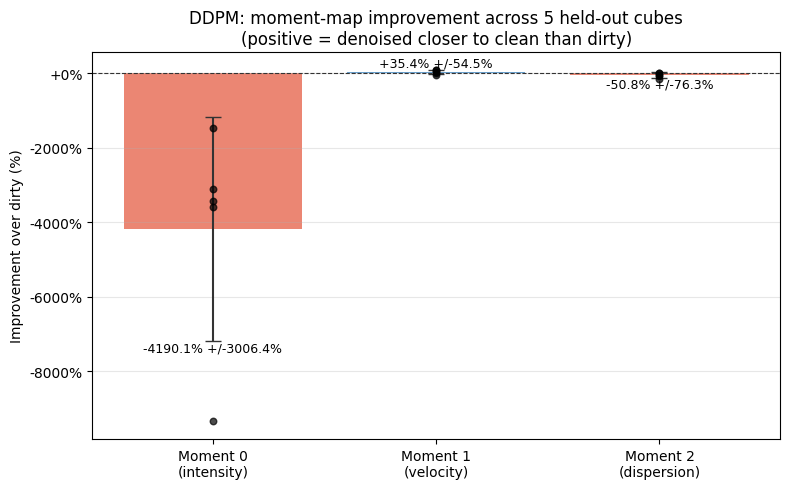

Chart saved -> ../results/moment_map_holdout_summary_ddpm.png


In [16]:
import csv
import gc
import matplotlib.ticker as mticker
import bettermoments as bm
from astropy.io import fits
from src.evaluation.moment_maps import generate_moment_maps
from src.data.fits_cube_dataset import continuum_of

OUT_DIR = '../results'         # DENOISE_BS_DDPM / SAMPLING_STEPS / K_AVG come from section 4
os.makedirs(OUT_DIR, exist_ok=True)

# The denoised cubes are 289 MB each and nothing downstream reads them back -- the moment
# maps are now built from the in-memory array instead of a write-then-reread round trip.
# Turn on only if the cubes themselves are wanted as an artifact.
SAVE_DENOISED_FITS = False

# Free the training model before sampling. Sections 7-10 leave `diffusion` alive with its
# Adam state and EMA shadow on the GPU; nothing below needs it, and section 11 allocates a
# second full DDPM on top.
for _stale in ('diffusion', '_probe'):
    if _stale in globals():
        del globals()[_stale]
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# fresh trainer <- best checkpoint (robust across restarts); EMA weights used for sampling
#
# data_parallel=False is deliberate and load-bearing. With 2 visible GPUs the default
# auto-enables nn.DataParallel, which re-replicates the model on EVERY forward call --
# and section 11 makes SAMPLING_STEPS * K_AVG = 100 calls per batch, ~1100 scatter/gather
# cycles before the twelfth batch. Two separate sessions hung there, at exactly 88/201
# channels, with no traceback and no output for hours before the watchdog killed the
# kernel: the signature of a DataParallel/NCCL deadlock, not of OOM (which raises) or a
# cuDNN fault (which segfaults promptly). DDIM sampling is sequential, so replicating
# across GPUs buys nothing here to trade against that risk.
eval_diff = DenoisingDiffusion(config=cfg, device=str(device), lr=LR_DDPM,
                               checkpoint_path=CKPT_DDPM, data_parallel=False)
eval_diff.load_checkpoint(CKPT_DDPM)
print('DDPM checkpoint loaded: epoch', eval_diff.start_epoch,
      '| best_val', round(float(eval_diff.best_val_loss), 4))
print('Evaluating', len(holdout_cubes), 'held-out cubes (DDIM sampling -- slow)...')

def _rss_gb():
    """Resident set size in GiB, read straight from /proc (no psutil dependency)."""
    try:
        for line in open('/proc/self/status'):
            if line.startswith('VmRSS:'):
                return int(line.split()[1]) / 2**20
    except Exception:
        return float('nan')
    return float('nan')


def _mem(tag):
    # Two sessions were killed by the host OOM killer with no traceback, at the same point
    # each time. Printing RSS around every large allocation turns the next failure into a
    # measurement instead of another inference.
    print('      [mem] {:<26} RSS {:.2f} GiB'.format(tag, _rss_gb()), flush=True)


def mdiff(a, b):
    mask = np.isfinite(a) & np.isfinite(b)
    return float(np.nanmean(np.abs(a[mask] - b[mask])))

def denoise_cube_ddpm(ho_entry, velax):
    """Denoise one cube, and collapse the DIRTY moments while only that cube is resident.

    Ordering is the whole point. Each cube is 201x600x600 float32 = 289 MB and
    generate_moment_maps allocates one more internally for the M2 noise clip. Collapsing
    dirty here, before the denoised cube is allocated, means dirty_csub can be freed first
    and the two never coexist -- the previous version held dirty_csub, the denoised cube
    and a third full copy of dirty simultaneously, and the kernel was killed by the host
    OOM killer at exactly that point on two runs.
    """
    with fits.open(ho_entry['dirty'], memmap=False) as hdul:
        dirty_raw = np.ascontiguousarray(hdul[0].data).astype(np.float32)
        hdr = hdul[0].header.copy()
    C, H, W = dirty_raw.shape
    dirty_csub = dirty_raw - continuum_of(dirty_raw, CONTINUUM_N)[None, :, :]
    del dirty_raw
    gc.collect()
    _mem('dirty loaded')

    dmaps = generate_moment_maps(None, data_velax=(dirty_csub, velax))
    _mem('dirty moments done')

    los  = dirty_csub.reshape(C, -1).min(axis=1)
    his  = dirty_csub.reshape(C, -1).max(axis=1)
    rngs = his - los
    norm = np.zeros_like(dirty_csub)
    nz = rngs > 0
    norm[nz] = (dirty_csub[nz] - los[nz, None, None]) / rngs[nz, None, None]
    del dirty_csub          # freed BEFORE the denoised cube is allocated
    gc.collect()

    denoised_csub = np.empty((C, H, W), dtype=np.float32)
    _mem('norm + denoised alloc')
    # Progress matters here: one cube is 201 channels x 25 DDIM steps x K_AVG draws,
    # so the cell can sit silent for many minutes and look hung.
    _nb = -(-C // DENOISE_BS_DDPM)
    print('    {} channels in {} batches of {} ({} model calls per batch)'.format(
        C, _nb, DENOISE_BS_DDPM, SAMPLING_STEPS * K_AVG), flush=True)
    _t0 = time.time()
    for s in range(0, C, DENOISE_BS_DDPM):
        t   = torch.from_numpy(norm[s:s+DENOISE_BS_DDPM])[:, None].float()          # (b,1,600,600) [0,1]
        t256 = F.interpolate(t, (TARGET_SIZE, TARGET_SIZE), mode='bilinear', align_corners=False)
        out  = eval_diff.sample(t256, sampling_timesteps=SAMPLING_STEPS, use_ema=True, n_avg=K_AVG)  # (b,1,256,256) [0,1]
        out600 = F.interpolate(out.cpu(), (H, W), mode='bilinear', align_corners=False)[:, 0].numpy()
        for k in range(out600.shape[0]):
            ch = s + k
            denoised_csub[ch] = (out600[k] * rngs[ch] + los[ch]) if rngs[ch] > 0 else \
                                np.full((H, W), los[ch], np.float32)
        _done = min(s + DENOISE_BS_DDPM, C)
        _el = time.time() - _t0
        _eta = _el / max(_done, 1) * (C - _done)
        # One line per batch, NOT a '\r'-rewritten status line: a carriage return is
        # rewritten in a live browser but dropped from Kaggle's saved/committed log, so
        # the only progress indicator vanished in exactly the runs that needed it -- a
        # slow-but-working run looked byte-identical to a hung one.
        print('    {:>3}/{} channels | {:.1f} min elapsed, ~{:.1f} min left'.format(
            _done, C, _el / 60, _eta / 60), flush=True)
    del norm
    gc.collect()
    _mem('sampling done, norm freed')
    if SAVE_DENOISED_FITS:
        out_path = os.path.join(OUT_DIR, 'denoised_ddpm_' + ho_entry['folder'] + '.fits')
        fits.writeto(out_path, denoised_csub, header=hdr, overwrite=True)
        print('    wrote', os.path.basename(out_path), flush=True)
    return denoised_csub, dmaps

csv_path = os.path.join(OUT_DIR, 'moment_map_holdout_summary_ddpm.csv')

def _completed_cubes(path):
    """Cube rows already scored, so a resumed session skips them.

    Each cube is 15-45 min of DDIM sampling and the whole cell used to be
    all-or-nothing: a session that died on cube 4 threw away cubes 1-3. Rows are
    appended as each cube finishes, and MEAN/STD summary rows are ignored here."""
    out = {}
    if not os.path.exists(path):
        return out
    with open(path, newline='') as f:
        for r in csv.DictReader(f):
            cube = (r.get('cube') or '').strip()
            if cube in ('', 'MEAN', 'STD') or not r.get('imp_M0'):
                continue
            try:
                out[cube] = {'cube': cube,
                             **{k: float(r[k]) for k in r if k != 'cube' and r[k] not in ('', None)}}
            except ValueError:
                continue
    return out

done_cubes = _completed_cubes(csv_path)
if done_cubes:
    print(f'[resume] {len(done_cubes)} cube(s) already scored, will be skipped: '
          f'{sorted(done_cubes)}')

rows_data = []
col_w = 30
hdr_line = '{:<{w}} {:>10} {:>10} {:>10} {:>10} {:>10} {:>10}'.format(
    'cube', 'dirty_M0', 'imp_M0%', 'dirty_M1', 'imp_M1%', 'dirty_M2', 'imp_M2%', w=col_w)
print('\n' + hdr_line); print('-' * len(hdr_line))

for ho in holdout_cubes:
    if ho['folder'] in done_cubes:
        rows_data.append(done_cubes[ho['folder']])
        r = done_cubes[ho['folder']]
        print('  {:<24} SKIPPED (already scored)  M0 {:>7.1f}%  M1 {:>7.1f}%  M2 {:>7.1f}%'.format(
            ho['folder'], r['imp_M0'], r['imp_M1'], r['imp_M2']))
        continue
    print('  denoising', ho['folder'], '...', flush=True)
    _mem('cube start')

    # THE LEAK: this was `_, velax = bm.load_cube(...)`. bettermoments returns the whole
    # cube as float64 -- 201x600x600x8 = 579 MB -- and binding it to `_` kept it alive for
    # the rest of the iteration, through all three moment collapses, purely to obtain a
    # 201-element velocity axis. Only velax is wanted; drop the payload immediately.
    _cube, velax = bm.load_cube(ho['dirty'])
    del _cube
    gc.collect()
    _mem('velax read, cube freed')

    denoised_cube, (d0, d1, d2) = denoise_cube_ddpm(ho, velax)

    n0, n1, n2 = generate_moment_maps(None, data_velax=(denoised_cube, velax))
    del denoised_cube
    gc.collect()
    _mem('denoised moments done')

    with fits.open(ho['clean'], memmap=False) as h:
        clean_csub = np.ascontiguousarray(h[0].data).astype(np.float32)
    clean_csub -= continuum_of(clean_csub, CONTINUUM_N)[None]     # in place: no second copy
    c0, c1, c2 = generate_moment_maps(None, data_velax=(clean_csub, velax))
    del clean_csub
    gc.collect()
    _mem('clean moments done')
    row = {'cube': ho['folder']}
    for nm, cl, di, no in [('M0', c0, d0, n0), ('M1', c1, d1, n1), ('M2', c2, d2, n2)]:
        dd = mdiff(cl, di); nn = mdiff(cl, no)
        imp = 100.0 * (1 - nn / dd) if dd > 0 else float('nan')
        row['dirty_' + nm] = round(dd, 6); row['imp_' + nm] = round(imp, 2)
    rows_data.append(row)
    # append as each cube finishes, so a timeout costs one cube instead of all five
    _new = not os.path.exists(csv_path)
    with open(csv_path, 'a', newline='') as _cf:
        _w = csv.DictWriter(_cf, fieldnames=['cube', 'dirty_M0', 'imp_M0', 'dirty_M1',
                                             'imp_M1', 'dirty_M2', 'imp_M2'])
        if _new:
            _w.writeheader()
        _w.writerow(row)
    print('{:<{w}} {:>10.4g} {:>9.1f}% {:>10.4g} {:>9.1f}% {:>10.4g} {:>9.1f}%'.format(
        ho['folder'], row['dirty_M0'], row['imp_M0'], row['dirty_M1'], row['imp_M1'],
        row['dirty_M2'], row['imp_M2'], w=col_w))

moments = ['M0', 'M1', 'M2']
imps  = {m: [r['imp_'+m] for r in rows_data if r['imp_'+m] == r['imp_'+m]] for m in moments}
means = {m: float(np.mean(imps[m])) for m in moments}
stds  = {m: float(np.std(imps[m], ddof=1)) if len(imps[m]) > 1 else 0.0 for m in moments}
print('\n' + '=' * len(hdr_line))
print('DDPM SUMMARY (n=' + str(len(rows_data)) + ' cubes):')
for m in moments:
    print('  ' + m + ': mean {:+.1f}%  std {:.1f}%  (n={})'.format(means[m], stds[m], len(imps[m])))

fieldnames = ['cube', 'dirty_M0', 'imp_M0', 'dirty_M1', 'imp_M1', 'dirty_M2', 'imp_M2']
# rewritten in full here (mode 'w'), collapsing the incrementally appended rows and
# adding MEAN/STD -- so re-running never leaves duplicates behind
with open(csv_path, 'w', newline='') as cf:
    w = csv.DictWriter(cf, fieldnames=fieldnames); w.writeheader()
    for r in rows_data: w.writerow(r)
    w.writerow({'cube': 'MEAN', **{'imp_'+m: round(means[m],2) for m in moments},
                **{'dirty_'+m: '' for m in moments}})
    w.writerow({'cube': 'STD',  **{'imp_'+m: round(stds[m],2) for m in moments},
                **{'dirty_'+m: '' for m in moments}})
print('\nCSV saved ->', csv_path)

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(moments))
bar_means = [means[m] for m in moments]; bar_stds = [stds[m] for m in moments]
colors = ['#4E91C7' if v >= 0 else '#E8715A' for v in bar_means]
bars = ax.bar(x, bar_means, yerr=bar_stds, capsize=6, color=colors, alpha=0.85,
              error_kw=dict(elinewidth=1.5, ecolor='#333333'))
ax.axhline(0, color='#333333', lw=0.8, ls='--')
ax.set_xticks(x); ax.set_xticklabels(['Moment 0\n(intensity)','Moment 1\n(velocity)','Moment 2\n(dispersion)'])
ax.set_ylabel('Improvement over dirty (%)')
ax.set_title('DDPM: moment-map improvement across 5 held-out cubes\n(positive = denoised closer to clean than dirty)')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%+.0f%%'))
for bar, mv, sv in zip(bars, bar_means, bar_stds):
    ht = bar.get_height(); va = 'bottom' if ht >= 0 else 'top'
    ax.text(bar.get_x()+bar.get_width()/2, ht + (sv+2)*(1 if ht>=0 else -1),
            '{:+.1f}% +/-{:.1f}%'.format(mv, sv), ha='center', va=va, fontsize=9)
for i, m in enumerate(moments):
    ax.scatter([i]*len(imps[m]), imps[m], color='k', s=22, zorder=5, alpha=0.7)
ax.grid(axis='y', alpha=0.3); plt.tight_layout()
chart_path = os.path.join(OUT_DIR, 'moment_map_holdout_summary_ddpm.png')
plt.savefig(chart_path, dpi=140); plt.show()
print('Chart saved ->', chart_path)

## 12. Persist DDPM checkpoint to /kaggle/working (survives session end)

Copies the best DDPM checkpoint to the **top level** of `/kaggle/working` (outside the git
clone) so `kaggle kernels output <slug>` retrieves it directly. Save the notebook version
afterward so the `.pth.tar` is a downloadable output artifact.

In [17]:
import shutil
if ON_KAGGLE and os.path.exists(CKPT_DDPM):
    dst = '/kaggle/working/ddpm_line_emission_continuum_best.pth.tar'
    shutil.copy2(CKPT_DDPM, dst)
    print('checkpoint persisted ->', dst, '({:.1f} MB)'.format(os.path.getsize(dst)/1e6))
    src_csv = '../results/moment_map_holdout_summary_ddpm.csv'
    if os.path.exists(src_csv):
        shutil.copy2(src_csv, '/kaggle/working/moment_map_holdout_summary_ddpm.csv')
        print('summary CSV persisted -> /kaggle/working/moment_map_holdout_summary_ddpm.csv')
else:
    print('not on Kaggle (or checkpoint missing) -- skip persist. CKPT exists:', os.path.exists(CKPT_DDPM))

checkpoint persisted -> /kaggle/working/ddpm_line_emission_continuum_best.pth.tar (331.6 MB)
summary CSV persisted -> /kaggle/working/moment_map_holdout_summary_ddpm.csv


## Collect this notebook's outputs

Every artifact this notebook produced, copied into a **versioned run folder** together with
a manifest recording the commit, the UTC time and a checksum per file:

    <outputs>/06-ddpm-line-emission/<UTC timestamp>_<git sha>/

Nothing overwrites anything, so two runs can be compared directly. Results used to land in
one flat `results/` directory with no record of which notebook or which revision wrote them
-- a moment CSV from before the M2 noise-clip fix was indistinguishable from one after it.

On Kaggle this writes to `/kaggle/working/outputs/`, at the top level, so the bundle is
unambiguously part of the notebook Output rather than buried in the git clone. Download that
folder and commit it under `DENOISING_DIFFUSION/results/`.


In [18]:
from src.evaluation.collect_outputs import collect_outputs

_run_dir = collect_outputs(
    '06-ddpm-line-emission',
    [
        'moment_map_holdout_summary_ddpm.csv',
        'moment_map_holdout_summary_ddpm.png',
        'ddpm_line_emission_loss.png',
        'line_emission_ddpm_comparison.png',
        'ddpm_line_emission_continuum_best.pth.tar',
    ],
)


collected 5 file(s), 319.2 MiB -> /kaggle/working/outputs/06-ddpm-line-emission/2026-08-07T034744_d1f0f66
     316.22 MiB  ddpm_line_emission_continuum_best.pth.tar
       0.05 MiB  ddpm_line_emission_loss.png
       2.92 MiB  line_emission_ddpm_comparison.png
       0.00 MiB  moment_map_holdout_summary_ddpm.csv
       0.06 MiB  moment_map_holdout_summary_ddpm.png
